# 🔁 Wrapper Methods — Feature Selection

> **Folder:** `06_Feature_Selection`  
> **Notebook:** `wrapper_methods.ipynb`  
> **Author:** Hamna Munir

---

## 🎯 Objectives

By the end of this notebook, you will:

- Understand how **wrapper methods** differ from filter and embedded methods
- Implement **Recursive Feature Elimination (RFE)** and **RFECV**
- Run **Forward Selection** and **Backward Elimination** step by step
- Use **SequentialFeatureSelector** (sklearn's unified API)
- Compare feature subsets selected by different wrapper strategies
- Evaluate wrapper methods correctly inside a **Pipeline** to prevent leakage

---

## 📚 Techniques Covered

| # | Technique | Key Insight |
|---|-----------|-------------|
| 1 | Dataset Setup | High-dimensional classification + regression |
| 2 | RFE | Recursively eliminate least important features |
| 3 | RFECV | RFE with CV — auto-selects optimal k |
| 4 | Forward Selection | Add features one at a time greedily |
| 5 | Backward Elimination | Remove features one at a time greedily |
| 6 | SequentialFeatureSelector | sklearn unified forward/backward API |
| 7 | Wrapper vs Filter Comparison | Which features each method selects |
| 8 | Wrapper in Pipeline | Correct usage — no leakage |
| 9 | Stability Analysis | How stable are selected features across folds? |
| 10 | Summary & Golden Rules | Key takeaways |


---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import (
    RFE, RFECV,
    SequentialFeatureSelector,
    SelectKBest, f_classif, mutual_info_classif,
    VarianceThreshold,
)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'warning'  : '#F18F01',
    'purple'   : '#7B2D8B',
    'palette'  : ['#2E86AB','#E84855','#3BB273','#F18F01','#7B2D8B','#F4D35E'],
}
print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 1️⃣ Dataset Setup

> We create a high-dimensional dataset with **known informative features**  
> so we can verify whether wrapper methods correctly identify them.
>
> - 30 total features, only 8 are truly informative
> - 10 redundant (linear combinations of informative)
> - 12 noise features (completely uninformative)


In [2]:
np.random.seed(42)

# ── Classification (30 features, 8 informative) ───────────────────────────
X_clf, y_clf = make_classification(
    n_samples=600, n_features=30, n_informative=8,
    n_redundant=10, n_repeated=0, n_classes=2,
    weights=[0.5, 0.5], flip_y=0.05, random_state=42
)
feature_names = [f'F{i+1:02d}' for i in range(30)]
X_clf_df = pd.DataFrame(X_clf, columns=feature_names)
y_clf_s  = pd.Series(y_clf, name='Target')

# ── Regression (20 features, 6 informative) ───────────────────────────────
X_reg, y_reg = make_regression(
    n_samples=500, n_features=20, n_informative=6,
    noise=20, random_state=42
)
reg_feature_names = [f'R{i+1:02d}' for i in range(20)]
X_reg_df = pd.DataFrame(X_reg, columns=reg_feature_names)
y_reg_s  = pd.Series(y_reg, name='Target')

# ── Train/test split ──────────────────────────────────────────────────────
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_clf_df, y_clf_s, test_size=0.2, stratify=y_clf_s, random_state=42)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X_reg_df, y_reg_s, test_size=0.2, random_state=42)

print(f'Classification : {X_clf_df.shape} | '
      f'classes={dict(y_clf_s.value_counts().sort_index())}')
print(f'  Train: {Xc_tr.shape}  |  Test: {Xc_te.shape}')
print(f'Regression     : {X_reg_df.shape}')
print(f'  Train: {Xr_tr.shape}  |  Test: {Xr_te.shape}')
print()
print('True informative features (classification): F01–F08')
print('True informative features (regression)    : R01–R06')

Classification : (600, 30) | classes={0: 296, 1: 304}
  Train: (480, 30)  |  Test: (120, 30)
Regression     : (500, 20)
  Train: (400, 20)  |  Test: (100, 20)

True informative features (classification): F01–F08
True informative features (regression)    : R01–R06


---
## 2️⃣ Recursive Feature Elimination (RFE)

> RFE fits a model, ranks features by importance, removes the least important  
> feature(s), and repeats until the desired number of features remains.
>
> ```
> Step 1: Fit model on all d features
> Step 2: Rank features by importance (coef_ or feature_importances_)
> Step 3: Remove the bottom n_features_to_remove features
> Step 4: Repeat until k features remain
> ```
>
> **Best estimators for RFE:** any model with `coef_` or `feature_importances_`  
> → Logistic Regression, SVM (linear), Ridge, Random Forest, Gradient Boosting


RFE Results (Logistic Regression estimator):
 k  Accuracy  ROC-AUC                                                                                           Selected
 5    0.7917   0.8569                                                                            F11, F13, F15, F18, F24
 8    0.7917   0.8550                                                             F07, F11, F13, F15, F16, F18, F19, F24
10    0.7833   0.8530                                                   F07, F09, F11, F13, F15, F16, F18, F19, F20, F24
15    0.7750   0.8500                          F05, F07, F09, F10, F11, F13, F14, F15, F16, F18, F19, F20, F22, F24, F29
20    0.7583   0.8375 F04, F05, F06, F07, F09, F10, F11, F12, F13, F14, F15, F16, F18, F19, F20, F22, F24, F25, F27, F29

RFE Feature Rankings (k=8):
Feature  Rank  Selected
    F07     1      True
    F15     1      True
    F16     1      True
    F11     1      True
    F13     1      True
    F24     1      True
    F19     1      True
    F18 

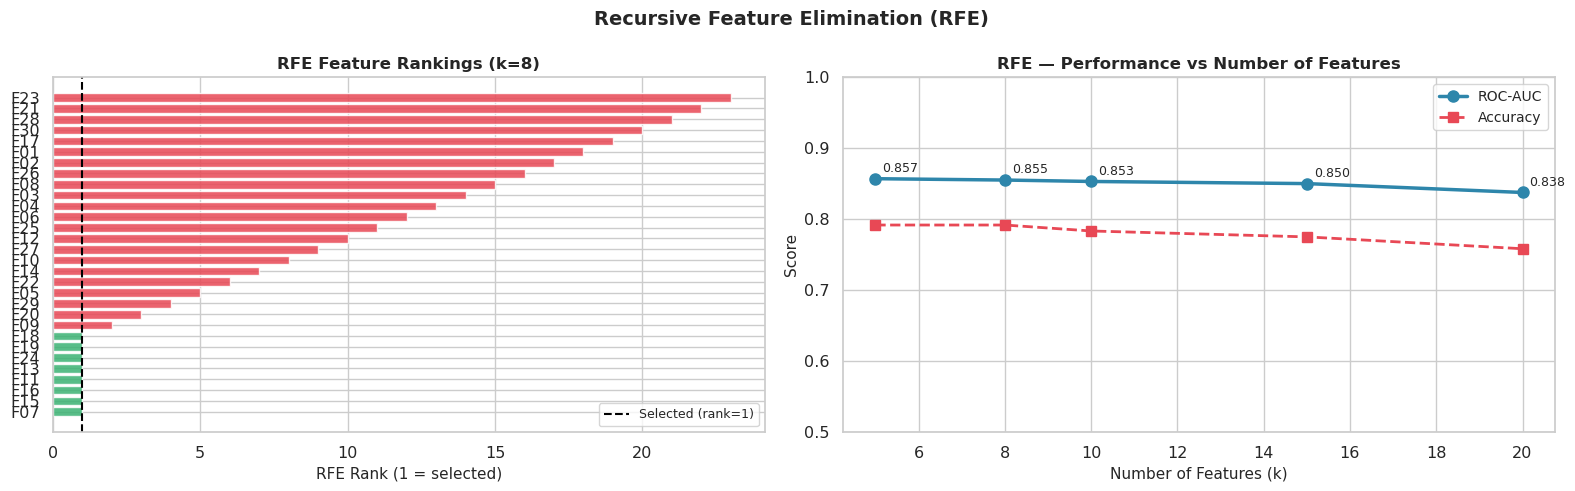

In [3]:
scaler = StandardScaler()
Xc_tr_sc = scaler.fit_transform(Xc_tr)
Xc_te_sc = scaler.transform(Xc_te)

# ── RFE with Logistic Regression ─────────────────────────────────────────
k_values = [5, 8, 10, 15, 20]
rfe_results = []

for k in k_values:
    rfe = RFE(
        estimator=LogisticRegression(max_iter=1000, random_state=42),
        n_features_to_select=k,
        step=1,           # remove 1 feature per iteration
    )
    rfe.fit(Xc_tr_sc, yc_tr)
    selected = np.array(feature_names)[rfe.support_].tolist()
    X_tr_sel = rfe.transform(Xc_tr_sc)
    X_te_sel = rfe.transform(Xc_te_sc)

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr_sel, yc_tr)
    acc  = accuracy_score(yc_te, model.predict(X_te_sel))
    auc  = roc_auc_score(yc_te, model.predict_proba(X_te_sel)[:,1])

    rfe_results.append({
        'k'         : k,
        'Selected'  : ', '.join(selected),
        'Accuracy'  : round(acc, 4),
        'ROC-AUC'   : round(auc, 4),
    })

rfe_df = pd.DataFrame(rfe_results)
print('RFE Results (Logistic Regression estimator):')
print(rfe_df[['k','Accuracy','ROC-AUC','Selected']].to_string(index=False))

# ── Feature ranking from RFE (k=8) ───────────────────────────────────────
rfe_8 = RFE(LogisticRegression(max_iter=1000, random_state=42),
            n_features_to_select=8, step=1)
rfe_8.fit(Xc_tr_sc, yc_tr)
ranking_df = pd.DataFrame({
    'Feature' : feature_names,
    'Rank'    : rfe_8.ranking_,
    'Selected': rfe_8.support_,
}).sort_values('Rank')

print(f'\nRFE Feature Rankings (k=8):')
print(ranking_df.to_string(index=False))

# Plot ranking
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors_rank = [COLORS['accent'] if s else COLORS['secondary']
               for s in ranking_df['Selected']]
axes[0].barh(ranking_df['Feature'], ranking_df['Rank'],
             color=colors_rank, alpha=0.85, edgecolor='white')
axes[0].axvline(1, color='black', linestyle='--', linewidth=1.5,
                label='Selected (rank=1)')
axes[0].set_xlabel('RFE Rank (1 = selected)', fontsize=11)
axes[0].set_title('RFE Feature Rankings (k=8)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# k vs AUC
axes[1].plot(rfe_df['k'], rfe_df['ROC-AUC'], 'o-',
             color=COLORS['primary'], linewidth=2.5, markersize=8)
axes[1].plot(rfe_df['k'], rfe_df['Accuracy'], 's--',
             color=COLORS['secondary'], linewidth=2, markersize=7,
             label='Accuracy')
for _, row in rfe_df.iterrows():
    axes[1].annotate(f'{row["ROC-AUC"]:.3f}',
                     (row['k'], row['ROC-AUC']),
                     textcoords='offset points', xytext=(5,5), fontsize=9)
axes[1].set_xlabel('Number of Features (k)', fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('RFE — Performance vs Number of Features', fontsize=12, fontweight='bold')
axes[1].legend(['ROC-AUC','Accuracy'], fontsize=10)
axes[1].set_ylim([0.5, 1.0])

plt.suptitle('Recursive Feature Elimination (RFE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3️⃣ RFECV — RFE with Cross-Validation (Auto-Select k)

> RFECV uses cross-validation to **automatically find the optimal number of features**.  
> It runs RFE for every possible k and picks the k with the best CV score.
>
> ✅ Best choice when you don't know how many features to keep.  
> ⚠️ Slower than plain RFE — runs CV for each k.


RFECV Results:
  Optimal k        : 7
  Selected features: ['F07', 'F11', 'F13', 'F15', 'F18', 'F19', 'F24']
  Best CV AUC      : 0.8483 ± 0.0441
  Test ROC-AUC     : 0.8569


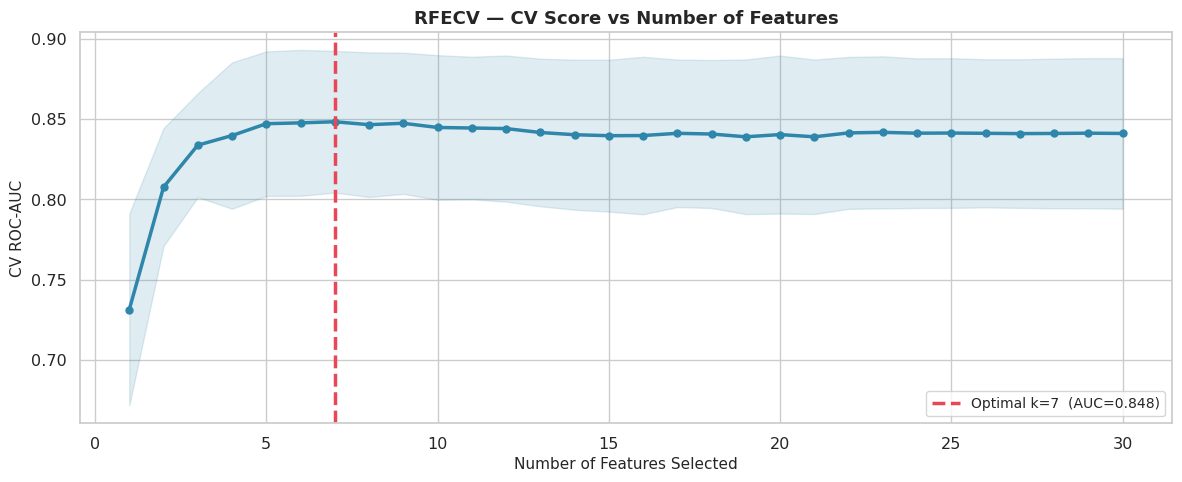

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    step=1,
    cv=skf,
    scoring='roc_auc',
    min_features_to_select=1,
    n_jobs=-1,
)
rfecv.fit(Xc_tr_sc, yc_tr)

optimal_k      = rfecv.n_features_
selected_feats = np.array(feature_names)[rfecv.support_].tolist()
cv_scores      = rfecv.cv_results_['mean_test_score']
cv_stds        = rfecv.cv_results_['std_test_score']

print(f'RFECV Results:')
print(f'  Optimal k        : {optimal_k}')
print(f'  Selected features: {selected_feats}')
print(f'  Best CV AUC      : {cv_scores[optimal_k-1]:.4f} ± {cv_stds[optimal_k-1]:.4f}')

# Test performance
X_tr_rfecv = rfecv.transform(Xc_tr_sc)
X_te_rfecv = rfecv.transform(Xc_te_sc)
model_rfecv = LogisticRegression(max_iter=1000, random_state=42)
model_rfecv.fit(X_tr_rfecv, yc_tr)
auc_rfecv = roc_auc_score(yc_te, model_rfecv.predict_proba(X_te_rfecv)[:,1])
print(f'  Test ROC-AUC     : {auc_rfecv:.4f}')

# Plot CV scores vs n_features
fig, ax = plt.subplots(figsize=(12, 5))
n_features_range = range(1, len(cv_scores)+1)
ax.plot(n_features_range, cv_scores, 'o-',
        color=COLORS['primary'], linewidth=2.5, markersize=5)
ax.fill_between(n_features_range,
                cv_scores - cv_stds,
                cv_scores + cv_stds,
                alpha=0.15, color=COLORS['primary'])
ax.axvline(optimal_k, color=COLORS['secondary'], linestyle='--',
           linewidth=2.5, label=f'Optimal k={optimal_k}  (AUC={cv_scores[optimal_k-1]:.3f})')
ax.set_xlabel('Number of Features Selected', fontsize=11)
ax.set_ylabel('CV ROC-AUC', fontsize=11)
ax.set_title('RFECV — CV Score vs Number of Features',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 4️⃣ Forward Selection — Add Features Greedily

> Forward Selection starts with **no features** and adds one at a time:
>
> ```
> Start: {} (empty set)
> Step 1: Try each feature alone → keep the one with best CV score
> Step 2: Try adding each remaining feature → keep the best combination
> Step 3: Repeat until k features selected
> ```
>
> ✅ Good when you expect a small number of relevant features  
> ⚠️ Can miss interactions — a bad feature alone may become good in combination


Forward Selection (k=8, Logistic Regression, ROC-AUC):
  Step  1: Added F18     CV roc_auc=0.7945  | Set: ['F18']
  Step  2: Added F11     CV roc_auc=0.8459  | Set: ['F18', 'F11']
  Step  3: Added F20     CV roc_auc=0.8514  | Set: ['F18', 'F11', 'F20']
  Step  4: Added F09     CV roc_auc=0.8525  | Set: ['F18', 'F11', 'F20', 'F09']
  Step  5: Added F10     CV roc_auc=0.8547  | Set: ['F18', 'F11', 'F20', 'F09', 'F10']
  Step  6: Added F07     CV roc_auc=0.8552  | Set: ['F18', 'F11', 'F20', 'F09', 'F10', 'F07']
  Step  7: Added F27     CV roc_auc=0.8556  | Set: ['F18', 'F11', 'F20', 'F09', 'F10', 'F07', 'F27']
  Step  8: Added F14     CV roc_auc=0.8566  | Set: ['F18', 'F11', 'F20', 'F09', 'F10', 'F07', 'F27', 'F14']

Final selected features: ['F18', 'F11', 'F20', 'F09', 'F10', 'F07', 'F27', 'F14']


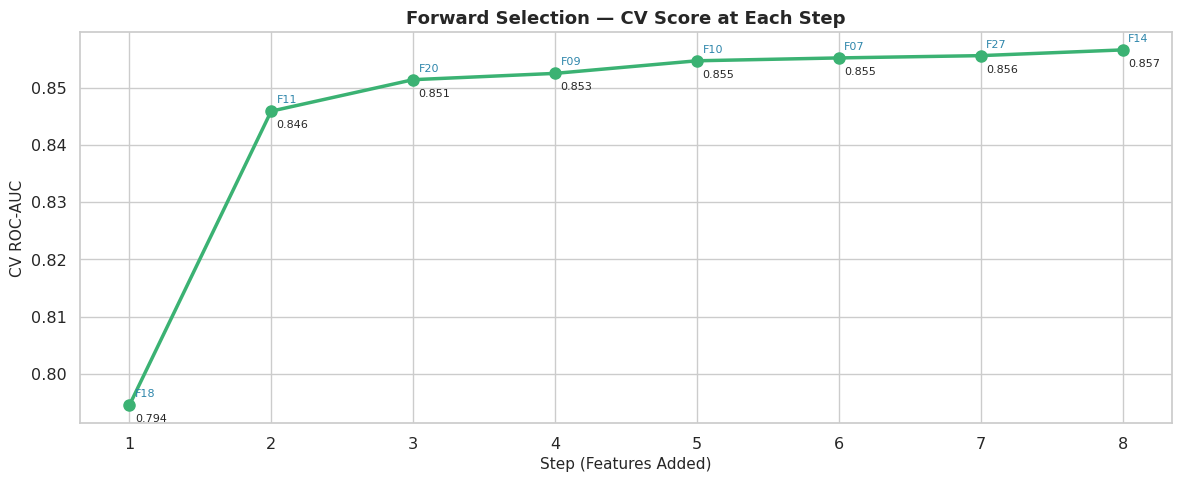

In [5]:
def forward_selection(X_train, y_train, feature_names, k,
                       estimator=None, cv=5, scoring='roc_auc'):
    """
    Greedy Forward Selection — manually implemented for transparency.
    Adds one feature at a time, keeping the best CV-scoring subset.
    """
    if estimator is None:
        estimator = LogisticRegression(max_iter=1000, random_state=42)

    skf_fs   = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    remaining = list(range(X_train.shape[1]))
    selected  = []
    history   = []

    for step in range(k):
        best_score  = -np.inf
        best_feat   = None

        for feat in remaining:
            candidate = selected + [feat]
            X_cand    = X_train[:, candidate]
            scores    = cross_val_score(estimator, X_cand, y_train,
                                        cv=skf_fs, scoring=scoring)
            score     = scores.mean()
            if score > best_score:
                best_score = score
                best_feat  = feat

        selected.append(best_feat)
        remaining.remove(best_feat)
        history.append({
            'Step'    : step + 1,
            'Added'   : feature_names[best_feat],
            'CV Score': round(best_score, 4),
            'Selected': [feature_names[i] for i in selected],
        })
        print(f'  Step {step+1:2d}: Added {feature_names[best_feat]:6s}  '
              f'CV {scoring}={best_score:.4f}  '
              f'| Set: {[feature_names[i] for i in selected]}')

    return selected, pd.DataFrame(history)

print('Forward Selection (k=8, Logistic Regression, ROC-AUC):')
fwd_selected, fwd_history = forward_selection(
    Xc_tr_sc, yc_tr.values, feature_names, k=8
)
print(f'\nFinal selected features: {[feature_names[i] for i in fwd_selected]}')

# Plot forward selection path
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(fwd_history['Step'], fwd_history['CV Score'], 'o-',
        color=COLORS['accent'], linewidth=2.5, markersize=8)
for _, row in fwd_history.iterrows():
    ax.annotate(row['Added'],
                (row['Step'], row['CV Score']),
                textcoords='offset points', xytext=(4, 6), fontsize=8,
                color=COLORS['primary'])
    ax.annotate(f'{row["CV Score"]:.3f}',
                (row['Step'], row['CV Score']),
                textcoords='offset points', xytext=(4, -12), fontsize=8)
ax.set_xlabel('Step (Features Added)', fontsize=11)
ax.set_ylabel('CV ROC-AUC', fontsize=11)
ax.set_title('Forward Selection — CV Score at Each Step',
             fontsize=13, fontweight='bold')
ax.set_xticks(fwd_history['Step'])
plt.tight_layout()
plt.show()

---
## 5️⃣ Backward Elimination — Remove Features Greedily

> Backward Elimination starts with **all features** and removes one at a time:
>
> ```
> Start: {all d features}
> Step 1: Try removing each feature → keep the removal that hurts the least
> Step 2: Repeat until k features remain
> ```
>
> ✅ Better than Forward when features interact (starts with full context)  
> ⚠️ Computationally expensive for very high-d data (each step fits d models)


Backward Elimination (→ k=8, Logistic Regression, ROC-AUC):
  Step  1: Removed F03     CV roc_auc=0.8434  | 29 remaining
  Step  2: Removed F17     CV roc_auc=0.8448  | 28 remaining
  Step  3: Removed F04     CV roc_auc=0.8476  | 27 remaining
  Step  4: Removed F22     CV roc_auc=0.8487  | 26 remaining
  Step  5: Removed F10     CV roc_auc=0.8505  | 25 remaining
  Step  6: Removed F25     CV roc_auc=0.8507  | 24 remaining
  Step  7: Removed F26     CV roc_auc=0.8507  | 23 remaining
  Step  8: Removed F06     CV roc_auc=0.8507  | 22 remaining
  Step  9: Removed F21     CV roc_auc=0.8508  | 21 remaining
  Step 10: Removed F16     CV roc_auc=0.8517  | 20 remaining
  Step 11: Removed F19     CV roc_auc=0.8522  | 19 remaining
  Step 12: Removed F30     CV roc_auc=0.8523  | 18 remaining
  Step 13: Removed F11     CV roc_auc=0.8524  | 17 remaining
  Step 14: Removed F23     CV roc_auc=0.8527  | 16 remaining
  Step 15: Removed F13     CV roc_auc=0.8541  | 15 remaining
  Step 16: Removed F12   

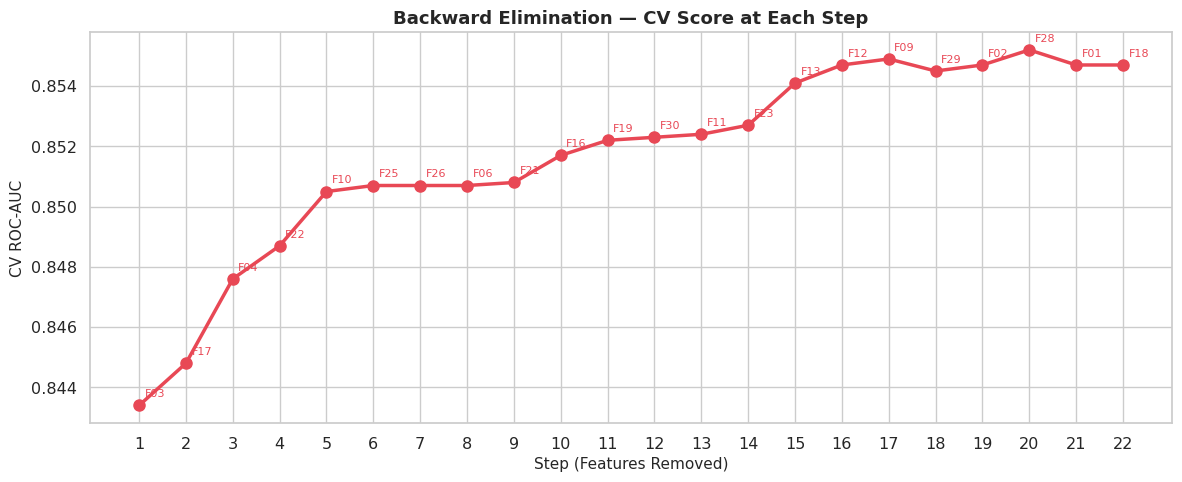

In [6]:
def backward_elimination(X_train, y_train, feature_names, k,
                          estimator=None, cv=5, scoring='roc_auc'):
    """
    Greedy Backward Elimination — removes least useful feature at each step.
    """
    if estimator is None:
        estimator = LogisticRegression(max_iter=1000, random_state=42)

    skf_be  = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    current = list(range(X_train.shape[1]))
    history = []

    while len(current) > k:
        best_score   = -np.inf
        worst_feat   = None

        for feat in current:
            candidate = [f for f in current if f != feat]
            X_cand    = X_train[:, candidate]
            scores    = cross_val_score(estimator, X_cand, y_train,
                                        cv=skf_be, scoring=scoring)
            score     = scores.mean()
            if score > best_score:
                best_score = score
                worst_feat = feat

        current.remove(worst_feat)
        history.append({
            'Step'     : X_train.shape[1] - len(current),
            'Removed'  : feature_names[worst_feat],
            'CV Score' : round(best_score, 4),
            'Remaining': len(current),
            'Features' : [feature_names[i] for i in current],
        })
        print(f'  Step {X_train.shape[1]-len(current):2d}: Removed {feature_names[worst_feat]:6s}  '
              f'CV {scoring}={best_score:.4f}  '
              f'| {len(current)} remaining')

    return current, pd.DataFrame(history)

print('Backward Elimination (→ k=8, Logistic Regression, ROC-AUC):')
bwd_selected, bwd_history = backward_elimination(
    Xc_tr_sc, yc_tr.values, feature_names, k=8
)
print(f'\nFinal selected features: {[feature_names[i] for i in bwd_selected]}')

# Plot backward elimination path
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(bwd_history['Step'], bwd_history['CV Score'], 'o-',
        color=COLORS['secondary'], linewidth=2.5, markersize=8)
for _, row in bwd_history.iterrows():
    ax.annotate(row['Removed'],
                (row['Step'], row['CV Score']),
                textcoords='offset points', xytext=(4, 6), fontsize=8,
                color=COLORS['secondary'])
ax.set_xlabel('Step (Features Removed)', fontsize=11)
ax.set_ylabel('CV ROC-AUC', fontsize=11)
ax.set_title('Backward Elimination — CV Score at Each Step',
             fontsize=13, fontweight='bold')
ax.set_xticks(bwd_history['Step'])
plt.tight_layout()
plt.show()

---
## 6️⃣ SequentialFeatureSelector — sklearn Unified API

> sklearn's `SequentialFeatureSelector` implements both forward and backward  
> selection with cross-validation in a clean, Pipeline-compatible API.
>
> | direction | Method |
> |-----------|--------|
> | `'forward'` | Forward Selection — add features |
> | `'backward'` | Backward Elimination — remove features |


  forward  k=5: AUC=0.8644 | ['F09', 'F10', 'F11', 'F18', 'F20']
  forward  k=8: AUC=0.8508 | ['F07', 'F09', 'F10', 'F11', 'F14', 'F18', 'F20', 'F27']
  forward  k=12: AUC=0.8383 | ['F01', 'F07', 'F09', 'F10', 'F11', 'F12', 'F14', 'F15', 'F18', 'F20', 'F27', 'F30']
  backward k=5: AUC=0.8483 | ['F07', 'F08', 'F15', 'F20', 'F24']
  backward k=8: AUC=0.8405 | ['F05', 'F07', 'F08', 'F14', 'F15', 'F20', 'F24', 'F27']
  backward k=12: AUC=0.8494 | ['F01', 'F02', 'F05', 'F07', 'F08', 'F14', 'F15', 'F18', 'F20', 'F24', 'F27', 'F28']

SequentialFeatureSelector Results:
Direction  k  Test AUC  Test Acc
  forward  5    0.8644    0.8000
  forward  8    0.8508    0.7917
  forward 12    0.8383    0.7667
 backward  5    0.8483    0.7750
 backward  8    0.8405    0.7833
 backward 12    0.8494    0.8000


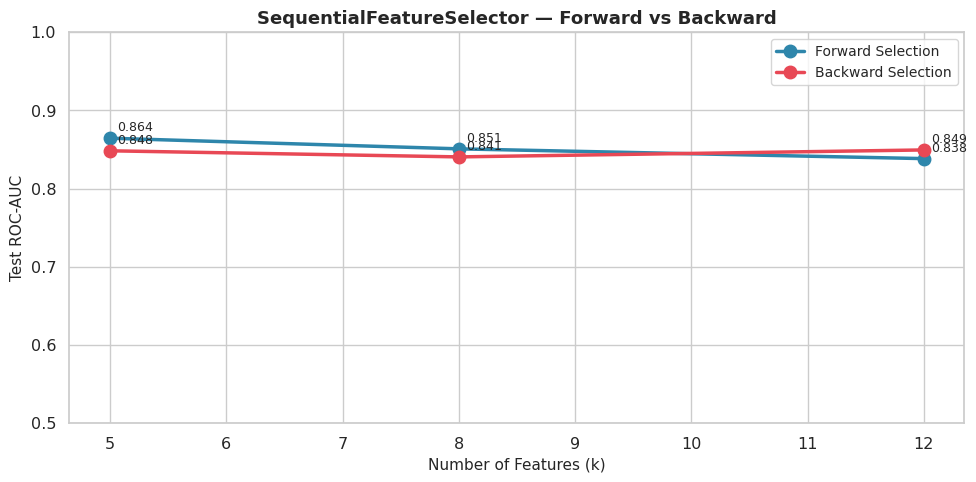

In [7]:
skf_sfs = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_sfs = []
for direction in ['forward', 'backward']:
    for k in [5, 8, 12]:
        sfs = SequentialFeatureSelector(
            estimator=LogisticRegression(max_iter=1000, random_state=42),
            n_features_to_select=k,
            direction=direction,
            scoring='roc_auc',
            cv=skf_sfs,
            n_jobs=-1,
        )
        sfs.fit(Xc_tr_sc, yc_tr)
        selected = np.array(feature_names)[sfs.get_support()].tolist()

        X_tr_sel = sfs.transform(Xc_tr_sc)
        X_te_sel = sfs.transform(Xc_te_sc)
        model    = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_tr_sel, yc_tr)
        auc = roc_auc_score(yc_te, model.predict_proba(X_te_sel)[:,1])
        acc = accuracy_score(yc_te, model.predict(X_te_sel))

        results_sfs.append({
            'Direction': direction,
            'k'        : k,
            'Test AUC' : round(auc, 4),
            'Test Acc' : round(acc, 4),
            'Features' : ', '.join(selected),
        })
        print(f'  {direction:8s} k={k}: AUC={auc:.4f} | {selected}')

sfs_df = pd.DataFrame(results_sfs)
print('\nSequentialFeatureSelector Results:')
print(sfs_df[['Direction','k','Test AUC','Test Acc']].to_string(index=False))

# Comparison plot
fig, ax = plt.subplots(figsize=(10, 5))
for direction, color in [('forward', COLORS['primary']), ('backward', COLORS['secondary'])]:
    subset = sfs_df[sfs_df['Direction'] == direction]
    ax.plot(subset['k'], subset['Test AUC'], 'o-',
            color=color, linewidth=2.5, markersize=9,
            label=f'{direction.capitalize()} Selection')
    for _, row in subset.iterrows():
        ax.annotate(f'{row["Test AUC"]:.3f}',
                    (row['k'], row['Test AUC']),
                    textcoords='offset points', xytext=(5,5), fontsize=9)

ax.set_xlabel('Number of Features (k)', fontsize=11)
ax.set_ylabel('Test ROC-AUC', fontsize=11)
ax.set_title('SequentialFeatureSelector — Forward vs Backward',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim([0.5, 1.0])
plt.tight_layout()
plt.show()

---
## 7️⃣ Wrapper vs Filter — Feature Overlap Comparison

> Different methods may select different features for the same k.  
> More overlap = more agreement across methods = higher confidence in selection.


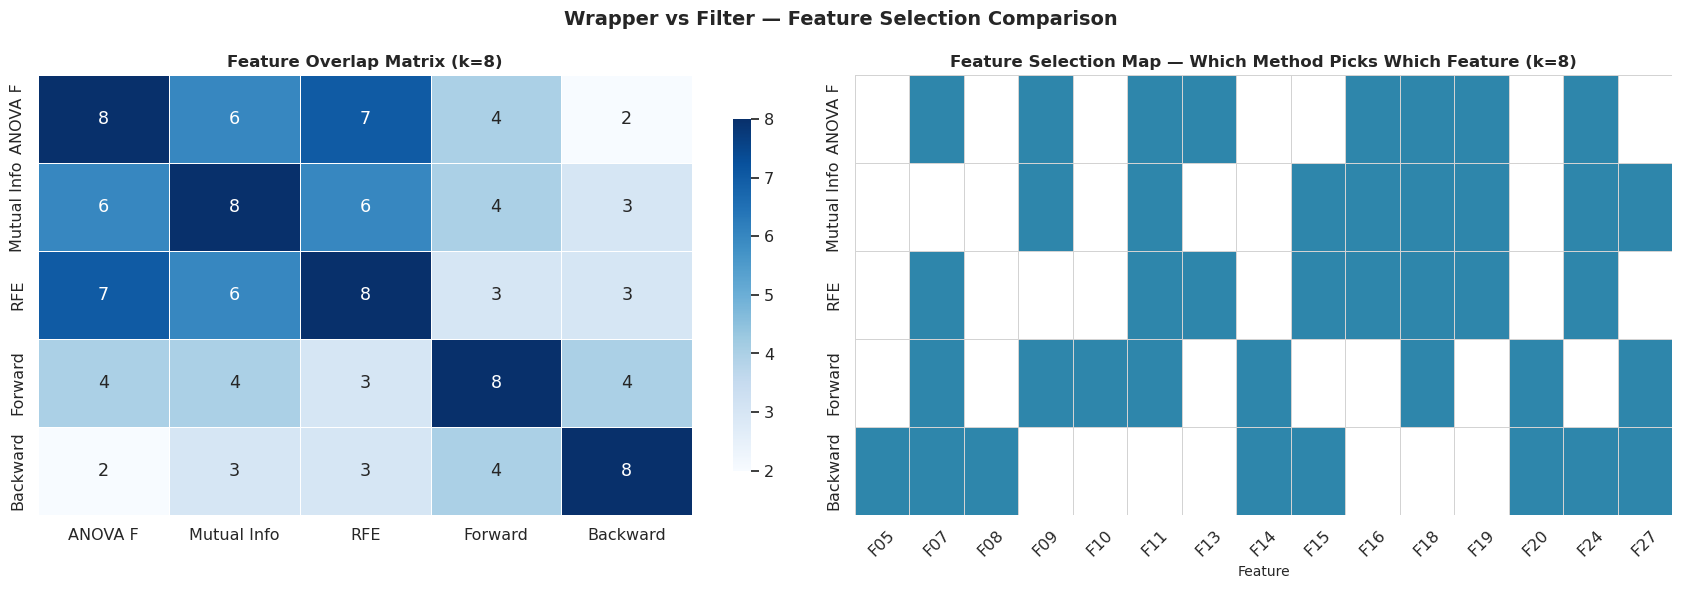

Consensus features (selected by ≥ 3 methods): ['F07', 'F09', 'F11', 'F15', 'F16', 'F18', 'F19', 'F24', 'F27']
Count per feature:
  F11: ████ (4/5 methods)
  F24: ████ (4/5 methods)
  F18: ████ (4/5 methods)
  F07: ████ (4/5 methods)
  F16: ███ (3/5 methods)
  F09: ███ (3/5 methods)
  F19: ███ (3/5 methods)
  F15: ███ (3/5 methods)
  F27: ███ (3/5 methods)
  F13: ██ (2/5 methods)
  F20: ██ (2/5 methods)
  F14: ██ (2/5 methods)
  F10: █ (1/5 methods)
  F05: █ (1/5 methods)
  F08: █ (1/5 methods)


In [8]:
k = 8

# Filter: SelectKBest f_classif
skb = SelectKBest(f_classif, k=k)
skb.fit(Xc_tr_sc, yc_tr)
filter_feats = set(np.array(feature_names)[skb.get_support()])

# Filter: Mutual Information
skb_mi = SelectKBest(mutual_info_classif, k=k)
skb_mi.fit(Xc_tr_sc, yc_tr)
mi_feats = set(np.array(feature_names)[skb_mi.get_support()])

# Wrapper: RFE
rfe_final = RFE(LogisticRegression(max_iter=1000, random_state=42),
                n_features_to_select=k, step=1)
rfe_final.fit(Xc_tr_sc, yc_tr)
rfe_feats = set(np.array(feature_names)[rfe_final.support_])

# Wrapper: Forward (from earlier)
fwd_feats = set(feature_names[i] for i in fwd_selected)

# Wrapper: Backward (from earlier)
bwd_feats = set(feature_names[i] for i in bwd_selected)

methods = {
    'Filter: ANOVA F'     : filter_feats,
    'Filter: Mutual Info' : mi_feats,
    'Wrapper: RFE'        : rfe_feats,
    'Wrapper: Forward'    : fwd_feats,
    'Wrapper: Backward'   : bwd_feats,
}

# Overlap matrix
method_names = list(methods.keys())
overlap_mat  = np.zeros((len(methods), len(methods)))
for i, (n1, s1) in enumerate(methods.items()):
    for j, (n2, s2) in enumerate(methods.items()):
        overlap_mat[i, j] = len(s1 & s2)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.heatmap(overlap_mat.astype(int), annot=True, fmt='d', cmap='Blues',
            xticklabels=[m.split(': ')[1] for m in method_names],
            yticklabels=[m.split(': ')[1] for m in method_names],
            ax=axes[0], linewidths=0.5, linecolor='white',
            cbar_kws={'shrink':0.8})
axes[0].set_title(f'Feature Overlap Matrix (k={k})',
                  fontsize=12, fontweight='bold')

# Feature frequency heatmap
all_features_sorted = sorted(feature_names)
presence = pd.DataFrame(index=method_names, columns=all_features_sorted, data=0)
for name, feats in methods.items():
    for f in feats:
        presence.loc[name, f] = 1

# Show only features selected by at least one method
cols_selected = presence.columns[presence.sum() > 0]
sns.heatmap(presence[cols_selected].astype(int),
            cmap=['white', COLORS['primary']],
            ax=axes[1], linewidths=0.5, linecolor='lightgray',
            cbar=False, yticklabels=[m.split(': ')[1] for m in method_names])
axes[1].set_title(f'Feature Selection Map — Which Method Picks Which Feature (k={k})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Wrapper vs Filter — Feature Selection Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Consensus features (selected by 3+ methods)
from collections import Counter
all_selected = [f for feats in methods.values() for f in feats]
counts       = Counter(all_selected)
consensus    = [f for f, c in counts.items() if c >= 3]
print(f'Consensus features (selected by ≥ 3 methods): {sorted(consensus)}')
print(f'Count per feature:')
for f, c in sorted(counts.items(), key=lambda x: -x[1]):
    bar = '█' * c
    print(f'  {f}: {bar} ({c}/5 methods)')

---
## 8️⃣ Wrapper Methods in a Pipeline — No Leakage

> ⚠️ **Critical:** Feature selection must happen **inside** cross-validation folds.  
> Fitting a selector on the full dataset before CV leaks test information.
>
> ✅ Always: `Pipeline([('scaler', ...), ('selector', RFE(...)), ('model', ...)])`


In [9]:
from sklearn.model_selection import cross_validate

# ── WRONG: select before CV ───────────────────────────────────────────────
rfe_wrong = RFE(LogisticRegression(max_iter=1000, random_state=42),
                n_features_to_select=8, step=1)
rfe_wrong.fit(Xc_tr_sc, yc_tr)   # fit on ALL train data
X_tr_wrong = rfe_wrong.transform(Xc_tr_sc)
X_te_wrong = rfe_wrong.transform(Xc_te_sc)

scores_wrong = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_tr_wrong, yc_tr,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc'
)

# ── CORRECT: RFE inside Pipeline ─────────────────────────────────────────
pipe_correct = Pipeline([
    ('scaler',   StandardScaler()),
    ('selector', RFE(LogisticRegression(max_iter=1000, random_state=42),
                     n_features_to_select=8, step=1)),
    ('model',    LogisticRegression(max_iter=1000, random_state=42)),
])

scores_correct = cross_val_score(
    pipe_correct,
    pd.concat([Xc_tr, Xc_te]), pd.concat([yc_tr, yc_te]),
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc'
)

print('⚠️  WRONG  (RFE fit before CV — leakage):')
print(f'   Scores: {[round(s,4) for s in scores_wrong]}')
print(f'   Mean  : {scores_wrong.mean():.4f} ± {scores_wrong.std():.4f}')
print()
print('✅ CORRECT (RFE inside Pipeline — no leakage):')
print(f'   Scores: {[round(s,4) for s in scores_correct]}')
print(f'   Mean  : {scores_correct.mean():.4f} ± {scores_correct.std():.4f}')
print()

# Compare multiple models in pipelines
model_configs = {
    'LR + RFE(k=8)'   : Pipeline([
        ('sc', StandardScaler()),
        ('sel', RFE(LogisticRegression(max_iter=1000, random_state=42),
                    n_features_to_select=8)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    'RF + RFE(k=8)'   : Pipeline([
        ('sc', StandardScaler()),
        ('sel', RFE(RandomForestClassifier(n_estimators=50, random_state=42),
                    n_features_to_select=8)),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ]),
    'LR (all 30 feats)': Pipeline([
        ('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42)),
    ]),
}

X_full = pd.concat([Xc_tr, Xc_te])
y_full = pd.concat([yc_tr, yc_te])
skf_pipe = StratifiedKFold(5, shuffle=True, random_state=42)

print('Pipeline CV Comparison:')
pipe_results = []
for name, pipe in model_configs.items():
    sc = cross_val_score(pipe, X_full, y_full, cv=skf_pipe, scoring='roc_auc')
    pipe_results.append({'Model': name, 'AUC Mean': round(sc.mean(),4),
                          'AUC Std': round(sc.std(),4)})
    print(f'  {name:25s}: {sc.mean():.4f} ± {sc.std():.4f}')

print(pd.DataFrame(pipe_results).to_string(index=False))

⚠️  WRONG  (RFE fit before CV — leakage):
   Scores: [0.8433, 0.8407, 0.9218, 0.7816, 0.8593]
   Mean  : 0.8494 ± 0.0448

✅ CORRECT (RFE inside Pipeline — no leakage):
   Scores: [0.8578, 0.8764, 0.83, 0.8469, 0.8144]
   Mean  : 0.8451 ± 0.0215

Pipeline CV Comparison:
  LR + RFE(k=8)            : 0.8451 ± 0.0215
  RF + RFE(k=8)            : 0.9117 ± 0.0134
  LR (all 30 feats)        : 0.8396 ± 0.0177
            Model  AUC Mean  AUC Std
    LR + RFE(k=8)    0.8451   0.0215
    RF + RFE(k=8)    0.9117   0.0134
LR (all 30 feats)    0.8396   0.0177


---
## 9️⃣ Stability Analysis — How Consistent is Feature Selection?

> A wrapper method is **stable** if it selects the same features  
> across different subsets of the data (different CV folds).
>
> **Instability** means the selected features are sensitive to which training  
> samples are used — a red flag for reliability.


Feature selection frequency across 10 folds (k=8):
Feature  RFE freq  Fwd freq
    F11        10        10
    F18        10        10
    F24        10         0
    F15         9         1
    F09         9         0
    F13         8         1
    F16         7         1
    F05         6         2
    F07         5         1
    F19         4         2
    F20         2         2
    F04         0         3
    F06         0         0
    F01         0         0
    F14         0         9
    F12         0         0
    F08         0         1
    F10         0         0
    F02         0         2
    F03         0         2
    F21         0         1
    F17         0         5
    F22         0         1
    F23         0         7
    F25         0         1
    F26         0         3
    F27         0         0
    F28         0         8
    F29         0         0
    F30         0         7


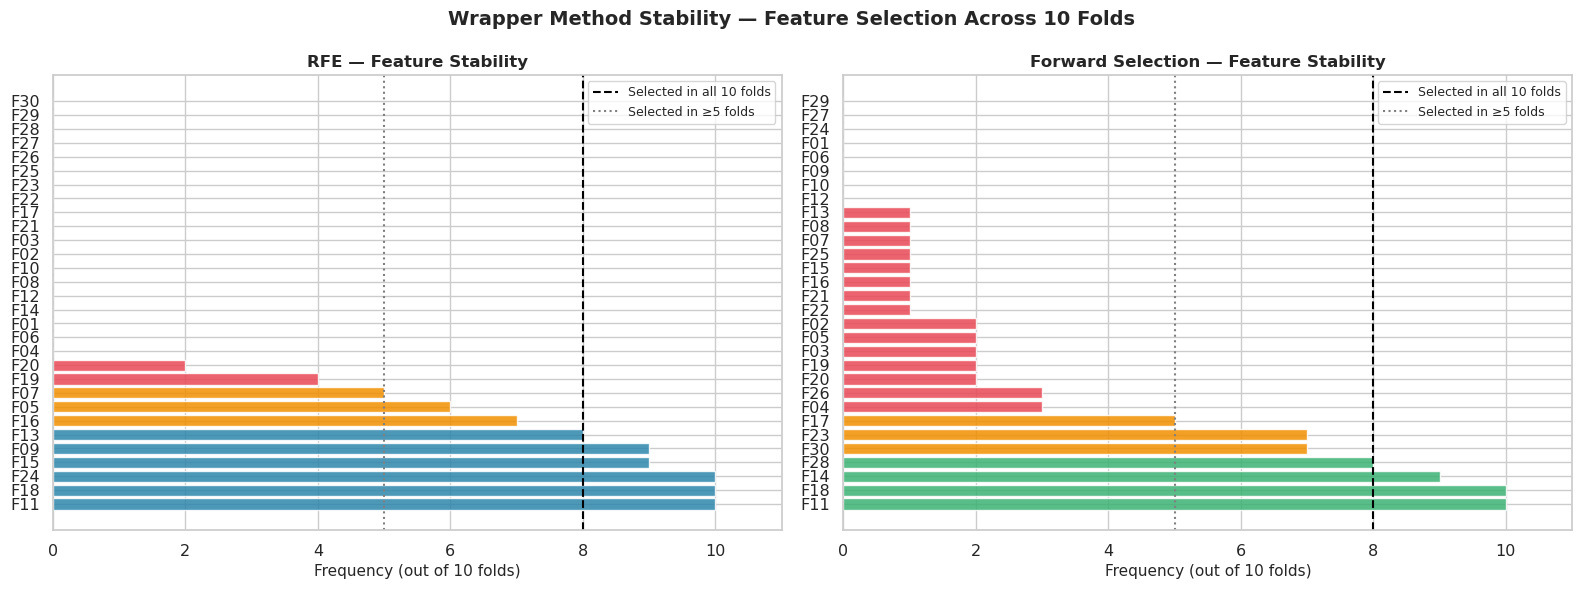


Stable features (≥8/10 folds) — RFE    : ['F11', 'F18', 'F24', 'F15', 'F09', 'F13']
Stable features (≥8/10 folds) — Forward: ['F11', 'F18', 'F14', 'F28']


In [10]:
skf_stab = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

X_all = np.vstack([Xc_tr_sc, Xc_te_sc])
y_all = np.concatenate([yc_tr.values, yc_te.values])

# Track selected features per fold for RFE and Forward
rfe_selections  = []
fwd_selections  = []

for fold, (tr_idx, te_idx) in enumerate(skf_stab.split(X_all, y_all)):
    X_fold_tr = X_all[tr_idx]
    y_fold_tr = y_all[tr_idx]

    # RFE
    rfe_fold = RFE(LogisticRegression(max_iter=1000, random_state=42),
                   n_features_to_select=8, step=1)
    rfe_fold.fit(X_fold_tr, y_fold_tr)
    rfe_selections.append(set(np.array(feature_names)[rfe_fold.support_]))

    # SequentialFeatureSelector (forward)
    sfs_fold = SequentialFeatureSelector(
        LogisticRegression(max_iter=1000, random_state=42),
        n_features_to_select=8, direction='forward',
        scoring='roc_auc', cv=3, n_jobs=-1,
    )
    sfs_fold.fit(X_fold_tr, y_fold_tr)
    fwd_selections.append(set(np.array(feature_names)[sfs_fold.get_support()]))

# Frequency of each feature across folds
rfe_freq = pd.Series({f: sum(f in s for s in rfe_selections)
                       for f in feature_names}).sort_values(ascending=False)
fwd_freq = pd.Series({f: sum(f in s for s in fwd_selections)
                       for f in feature_names}).sort_values(ascending=False)

print('Feature selection frequency across 10 folds (k=8):')
stability_df = pd.DataFrame({
    'Feature'  : feature_names,
    'RFE freq' : [rfe_freq[f] for f in feature_names],
    'Fwd freq' : [fwd_freq[f] for f in feature_names],
}).sort_values('RFE freq', ascending=False)
print(stability_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, freq, name, color in zip(
        axes,
        [rfe_freq, fwd_freq],
        ['RFE', 'Forward Selection'],
        [COLORS['primary'], COLORS['accent']]):
    bar_colors = [color if v >= 8 else COLORS['warning'] if v >= 5
                  else COLORS['secondary'] for v in freq.values]
    ax.barh(freq.index, freq.values, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axvline(8, color='black', linestyle='--', linewidth=1.5,
               label='Selected in all 10 folds')
    ax.axvline(5, color='gray', linestyle=':', linewidth=1.5,
               label='Selected in ≥5 folds')
    ax.set_xlabel('Frequency (out of 10 folds)', fontsize=11)
    ax.set_title(f'{name} — Feature Stability', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim([0, 11])

plt.suptitle('Wrapper Method Stability — Feature Selection Across 10 Folds',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Stable features (selected in ≥8/10 folds)
stable_rfe = rfe_freq[rfe_freq >= 8].index.tolist()
stable_fwd = fwd_freq[fwd_freq >= 8].index.tolist()
print(f'\nStable features (≥8/10 folds) — RFE    : {stable_rfe}')
print(f'Stable features (≥8/10 folds) — Forward: {stable_fwd}')

---
## ✅ 10. Summary & Golden Rules

| Method | Direction | Finds Interactions | Speed | sklearn Class |
|--------|:---------:|:-----------------:|:-----:|---------------|
| **RFE** | Backward (rank-based) | ⚠️ Partial | ✅ Fast | `RFE` |
| **RFECV** | Backward + CV | ⚠️ Partial | ⚠️ Medium | `RFECV` |
| **Forward Selection** | Forward | ⚠️ Partial | ⚠️ Medium | `SequentialFeatureSelector` |
| **Backward Elimination** | Backward | ✅ Better | ❌ Slow | `SequentialFeatureSelector` |

### 🔑 Golden Rules

1. **Always use wrapper methods inside a Pipeline** — prevents data leakage
2. **RFECV is the safest RFE variant** — auto-selects k via cross-validation
3. **RFE requires `coef_` or `feature_importances_`** — check estimator compatibility
4. **Forward selection is faster** than Backward for high-d data
5. **Backward elimination is more accurate** — starts with full feature context
6. **Run stability analysis** — if selected features vary wildly across folds, results are unreliable
7. **Compare against filter methods** — high overlap = high confidence in selection
8. **Use `SequentialFeatureSelector`** for sklearn-native forward/backward selection
9. **Wrapper methods are slow** on high-d data — pre-filter with `VarianceThreshold` or `SelectKBest` first
10. **Consensus features** (selected by multiple methods) are the most trustworthy

---

## 🔗 Next Steps

- ➡️ `06_Feature_Selection/filter_methods.md` — Fast statistical filters (χ², MI, ANOVA)
- ➡️ `06_Feature_Selection/embedded_methods.md` — Lasso, RF importance (built into training)
- ➡️ `07_Hyperparameter_Tuning/` — Tune k (number of features) alongside model params
- ➡️ `05_Model_Evaluation/cross_validation.ipynb` — Validate selected features properly
